In [1]:
import os
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm, LinearSegmentedColormap, BoundaryNorm, TwoSlopeNorm
from matplotlib.ticker import NullLocator, LogLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
import matplotlib.cm as cm

import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from scipy.stats import pearsonr, mannwhitneyu, zscore

from climada.entity.exposures import Exposures

# Configuration
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

# Default event frequency
DEFAULT_FREQ = 0.00067334  # events/year

In [2]:
def load_county_boundaries():
    """Load US county shapefile and filter to coastal states."""
    county_shp_path = Path("..") / "data" / "US_counties.shp"
    
    if not county_shp_path.exists():
        raise FileNotFoundError(f"County shapefile not found at {county_shp_path}")
    
    counties = gpd.read_file(county_shp_path)
    print(f"Loaded {len(counties)} counties")
    
    # Coastal state FIPS codes
    coastal_state_fips = [
        '01',  # Alabama
        '09',  # Connecticut
        '10',  # Delaware
        '12',  # Florida
        '13',  # Georgia
        '22',  # Louisiana
        '23',  # Maine
        '24',  # Maryland
        '25',  # Massachusetts
        '28',  # Mississippi
        '33',  # New Hampshire
        '34',  # New Jersey
        '36',  # New York
        '37',  # North Carolina
        '44',  # Rhode Island
        '45',  # South Carolina
        '48',  # Texas
        '51',  # Virginia
    ]
    
    coastal_counties = counties[counties["STATEFP"].isin(coastal_state_fips)].copy()
    
    # Create GEOID if not present
    if 'GEOID' not in coastal_counties.columns:
        if 'COUNTYFP' in coastal_counties.columns:
            coastal_counties['GEOID'] = coastal_counties['STATEFP'] + coastal_counties['COUNTYFP']
    
    print(f"Filtered to {len(coastal_counties)} coastal counties")
    
    return counties, coastal_counties


def load_construction_capacity():
    """Load construction capacity data from building permits."""
    permits_file = Path("..") / "data" / "selected_states_counties_with_permits.csv"
    
    permits_df = pd.read_csv(permits_file)
    permits_df['fips'] = permits_df['FIPS'].astype(str).str.zfill(5)
    
    capacity_df = permits_df[['fips', 'Average_Building_Permits(12 months)']].copy()
    capacity_df.columns = ['fips', 'construction_capacity']
    
    print(f"Loaded construction capacity for {len(capacity_df)} counties")
    print(f"  Range: {capacity_df['construction_capacity'].min():.1f} - "
          f"{capacity_df['construction_capacity'].max():.1f} permits/month")
    
    return capacity_df


def compute_expected_annual_damage():
    """Compute Expected Annual Damage (EAD) per damage state from event files."""
    print("=== Computing Expected Annual Damage (Units) per Damage State ===\n")
    
    by_event_dir = Path("..") / "impacts_out" / "by_event" / "scaled"
    event_files = sorted(by_event_dir.glob("*_scaled.csv"))
    print(f"Found {len(event_files)} event impact files")
    
    # Load and combine all files
    all_units = []
    for f in event_files:
        df = pd.read_csv(f)
        df_units = df[['event_name', 'fips', 'units_DS1_scaled', 'units_DS2_scaled', 
                        'units_DS3_scaled', 'units_DS4_scaled']].copy()
        all_units.append(df_units)
    
    units_df = pd.concat(all_units, ignore_index=True)
    print(f"Loaded {len(units_df)} county-event pairs")
    
    # Ensure FIPS is 5-digit zero-padded string
    units_df['fips'] = units_df['fips'].astype(str).str.zfill(5)
    
    # Compute EAD by multiplying units by event frequency
    for ds in ['DS1', 'DS2', 'DS3', 'DS4']:
        units_df[f'weighted_{ds}'] = units_df[f'units_{ds}_scaled'] * DEFAULT_FREQ
    
    # Sum across events per county
    ead_computed = units_df.groupby('fips').agg({
        'weighted_DS1': 'sum',
        'weighted_DS2': 'sum',
        'weighted_DS3': 'sum',
        'weighted_DS4': 'sum',
        'event_name': 'count'
    }).reset_index()
    
    ead_computed.columns = ['fips', 'DS1', 'DS2', 'DS3', 'DS4', 'num_events']
    
    print(f"\n=== Expected Annual Damage Statistics ===")
    print(f"Counties with data: {len(ead_computed)}")
    for ds in ['DS1', 'DS2', 'DS3', 'DS4']:
        total = ead_computed[ds].sum()
        print(f"  {ds}: Total={total:,.1f} units/yr")
    
    # Convert to long format
    ead_df = pd.melt(ead_computed, id_vars=['fips'], 
                     value_vars=['DS1', 'DS2', 'DS3', 'DS4'],
                     var_name='DS', value_name='ead')
    ead_df['type'] = 'scaled'
    
    # Also create wide format for easy analysis
    ead_wide = ead_df.pivot(index='fips', columns='DS', values='ead').reset_index()
    ead_wide.columns.name = None
    ead_wide['fips'] = ead_wide['fips'].astype(str).str.zfill(5)
    ead_wide['total_ead'] = ead_wide[['DS1', 'DS2', 'DS3', 'DS4']].sum(axis=1)
    
    return ead_df, ead_wide, units_df


def load_recovery_potential_data():
    """Load per-event recovery potential data."""
    print("=== Loading Recovery Potential Data ===\n")
    
    recovery_per_event_dir = Path("..") / "data" / "recovery_potential_per_scenario"
    recovery_files = list(recovery_per_event_dir.glob("*_scaled_recovery_potential.json"))
    
    print(f"Found {len(recovery_files)} recovery potential files")
    print("Loading all files (this may take a moment)...")
    
    all_recovery_events = []
    for idx, f in enumerate(recovery_files):
        if (idx + 1) % 500 == 0:
            print(f"  Loaded {idx + 1}/{len(recovery_files)} files...")
        
        with open(f, 'r') as file:
            data = json.load(file)
            df = pd.DataFrame(data)
            all_recovery_events.append(df)
    
    recovery_all_events = pd.concat(all_recovery_events, ignore_index=True)
    print(f"\nLoaded {len(recovery_all_events)} rows from "
          f"{recovery_all_events['event'].nunique()} unique events")
    
    # Ensure FIPS is 5-digit string
    recovery_all_events['fips'] = recovery_all_events['fips'].astype(str).str.zfill(5)
    
    # Handle infinity values (capacity = 0)
    recovery_all_events['recovery_potential [months]'] = (
        recovery_all_events['recovery_potential [months]']
        .replace([np.inf, -np.inf], np.nan)
    )
    
    return recovery_all_events


def compute_expected_annual_recovery_potential(recovery_all_events):
    """Compute Expected Annual Recovery Potential (EARP) per county."""
    print("\n=== Computing EARP (Expected Annual Recovery Potential) ===\n")
    
    # Multiply recovery potential by event frequency
    recovery_all_events['weighted_recovery'] = (
        recovery_all_events['recovery_potential [months]'] * DEFAULT_FREQ
    )
    
    # Sum across events per county
    earp_df = recovery_all_events.groupby('fips').agg({
        'weighted_recovery': 'sum',
        'recovery_potential [months]': ['count', 'sum', 'mean', 'max']
    }).reset_index()
    
    earp_df.columns = ['fips', 'earp_months_per_year', 'num_events', 
                       'total_recovery_months', 'mean_recovery_per_event', 'max_recovery']
    
    # Replace infinities with NaN
    earp_df = earp_df.replace([np.inf, -np.inf], np.nan)
    
    print(f"Computed EARP for {len(earp_df)} counties")
    earp_finite = earp_df['earp_months_per_year'].dropna()
    if len(earp_finite) > 0:
        print(f"  Mean EARP: {earp_finite.mean():.4f} months/year")
        print(f"  Median EARP: {earp_finite.median():.4f} months/year")
    
    return earp_df

In [3]:
def prepare_annual_driver_analysis(earp_df, ead_wide, capacity_df):
    """Prepare dataset for annual driver analysis."""
    print("\n=== Preparing Data for Annual Driver Analysis ===\n")
    
    # Merge EARP, EAD, and capacity
    driver_analysis = earp_df[['fips', 'earp_months_per_year']].copy()
    driver_analysis = driver_analysis.merge(ead_wide[['fips', 'total_ead']], 
                                           on='fips', how='inner')
    driver_analysis = driver_analysis.merge(capacity_df, on='fips', how='inner')
    
    # Remove invalid values
    driver_analysis = driver_analysis[
        (driver_analysis['earp_months_per_year'] > 0) & 
        (driver_analysis['total_ead'] > 0) & 
        (driver_analysis['construction_capacity'] > 0)
    ]
    
    print(f"Counties with complete data: {len(driver_analysis)}")
    
    # Log-transform for correlations
    driver_analysis['log_earp'] = np.log10(driver_analysis['earp_months_per_year'])
    driver_analysis['log_risk'] = np.log10(driver_analysis['total_ead'])
    driver_analysis['log_capacity'] = np.log10(driver_analysis['construction_capacity'])
    
    return driver_analysis


def prepare_per_event_analysis(recovery_all_events, units_df, capacity_df):
    """Prepare dataset for per-event analysis using median values."""
    print("\n=== Preparing Per-Event Metrics ===\n")
    
    # Mean and median recovery time per event for each county
    per_event_recovery = recovery_all_events.groupby('fips')['recovery_potential [months]'].agg(
        ['mean', 'median', 'count']
    ).reset_index()
    per_event_recovery.columns = ['fips', 'mean_recovery_months', 
                                   'median_recovery_months', 'num_events']
    
    # Mean and median damage per event for each county
    per_event_damage = units_df.groupby('fips')[[
        'units_DS1_scaled', 'units_DS2_scaled', 
        'units_DS3_scaled', 'units_DS4_scaled'
    ]].agg(['mean', 'median']).reset_index()
    
    # Flatten column names
    per_event_damage.columns = ['fips', 'DS1_mean', 'DS1_median', 
                                 'DS2_mean', 'DS2_median',
                                 'DS3_mean', 'DS3_median', 
                                 'DS4_mean', 'DS4_median']
    
    # Calculate total damage
    per_event_damage['mean_damage_units'] = (
        per_event_damage[['DS1_mean', 'DS2_mean', 'DS3_mean', 'DS4_mean']].sum(axis=1)
    )
    per_event_damage['median_damage_units'] = (
        per_event_damage[['DS1_median', 'DS2_median', 'DS3_median', 'DS4_median']].sum(axis=1)
    )
    
    # Merge with capacity
    per_event_analysis = per_event_recovery.merge(per_event_damage, on='fips', how='inner')
    per_event_analysis = per_event_analysis.merge(capacity_df, on='fips', how='inner')
    
    # Filter to valid median data
    per_event_analysis_median = per_event_analysis[
        (per_event_analysis['median_recovery_months'] > 0) & 
        (per_event_analysis['median_damage_units'] > 0) & 
        (per_event_analysis['construction_capacity'] > 0)
    ].copy()
    
    print(f"Counties with complete per-event MEDIAN data: {len(per_event_analysis_median)}")
    
    # Log-transform
    per_event_analysis_median['log_recovery'] = np.log10(
        per_event_analysis_median['median_recovery_months']
    )
    per_event_analysis_median['log_damage'] = np.log10(
        per_event_analysis_median['median_damage_units']
    )
    per_event_analysis_median['log_capacity'] = np.log10(
        per_event_analysis_median['construction_capacity']
    )
    
    return per_event_analysis_median


In [4]:
def compute_correlations_annual(driver_analysis):
    """Compute correlations for annual metrics."""
    print("\n=== Correlation Analysis: Annual Metrics ===\n")
    
    corr_earp_risk, p_earp_risk = pearsonr(
        driver_analysis['log_earp'], 
        driver_analysis['log_risk']
    )
    corr_earp_capacity, p_earp_capacity = pearsonr(
        driver_analysis['log_earp'], 
        driver_analysis['log_capacity']
    )
    
    print(f"EARP vs Risk (EAD):      {corr_earp_risk:+.3f} (p={p_earp_risk:.2e})")
    print(f"EARP vs Capacity:        {corr_earp_capacity:+.3f} (p={p_earp_capacity:.2e})")
    
    return {
        'corr_risk': corr_earp_risk,
        'p_risk': p_earp_risk,
        'corr_capacity': corr_earp_capacity,
        'p_capacity': p_earp_capacity
    }


def compute_correlations_per_event(per_event_analysis_median):
    """Compute correlations for per-event metrics."""
    print("\n=== Correlation Analysis: Per-Event Metrics ===\n")
    
    corr_recovery_damage, p_recovery_damage = pearsonr(
        per_event_analysis_median['log_recovery'], 
        per_event_analysis_median['log_damage']
    )
    corr_recovery_capacity, p_recovery_capacity = pearsonr(
        per_event_analysis_median['log_recovery'], 
        per_event_analysis_median['log_capacity']
    )
    
    print(f"Recovery vs Damage:   {corr_recovery_damage:+.3f} (p={p_recovery_damage:.2e})")
    print(f"Recovery vs Capacity: {corr_recovery_capacity:+.3f} (p={p_recovery_capacity:.2e})")
    
    return {
        'corr_damage': corr_recovery_damage,
        'p_damage': p_recovery_damage,
        'corr_capacity': corr_recovery_capacity,
        'p_capacity': p_recovery_capacity
    }

In [5]:
def variance_partitioning(y, X1, X2, var1_name='Variable 1', var2_name='Variable 2'):
    """
    Partition variance explained by two predictors into unique and shared components.
    
    Parameters
    -----------
    y : array-like
        Response variable (e.g., log recovery time)
    X1 : array-like
        First predictor (e.g., log damage)
    X2 : array-like
        Second predictor (e.g., log capacity)
    
    Returns
    --------
    dict with variance components and model info
    """
    # Ensure 2D arrays
    X1 = np.array(X1).reshape(-1, 1)
    X2 = np.array(X2).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    
    # Fit individual models
    model_1 = LinearRegression().fit(X1, y)
    model_2 = LinearRegression().fit(X2, y)
    
    # Fit combined model
    X_both = np.hstack([X1, X2])
    model_both = LinearRegression().fit(X_both, y)
    
    # Calculate R² values
    r2_1 = r2_score(y, model_1.predict(X1))
    r2_2 = r2_score(y, model_2.predict(X2))
    r2_both = r2_score(y, model_both.predict(X_both))
    
    # Variance partitioning
    unique_1 = r2_both - r2_2
    unique_2 = r2_both - r2_1
    shared = r2_1 + r2_2 - r2_both
    unexplained = 1 - r2_both
    
    # Get standardized coefficients
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_both_std = scaler_X.fit_transform(X_both)
    y_std = scaler_y.fit_transform(y)
    model_both_std = LinearRegression().fit(X_both_std, y_std)
    
    return {
        'r2_var1': r2_1,
        'r2_var2': r2_2,
        'r2_combined': r2_both,
        'unique_var1': unique_1,
        'unique_var2': unique_2,
        'shared': shared,
        'unexplained': unexplained,
        'beta_var1': model_both_std.coef_[0][0],
        'beta_var2': model_both_std.coef_[0][1],
        'model_both': model_both,
        'var1_name': var1_name,
        'var2_name': var2_name
    }


def perform_variance_partitioning_analysis(driver_analysis, per_event_analysis_median):
    """Perform variance partitioning for both annual and per-event metrics."""
    print("\n" + "="*80)
    print("VARIANCE PARTITIONING ANALYSIS")
    print("="*80)
    
    # Annual metrics
    print("\n--- ANNUAL METRICS (EARP) ---")
    y_annual = driver_analysis['log_earp'].values
    X_damage_annual = driver_analysis['log_risk'].values
    X_capacity_annual = driver_analysis['log_capacity'].values
    
    vp_annual = variance_partitioning(
        y_annual, X_damage_annual, X_capacity_annual,
        var1_name='EAD (Annual Damage)', var2_name='Construction Capacity'
    )
    
    print(f"R² Combined: {vp_annual['r2_combined']:.4f}")
    print(f"  Unique to Damage:   {vp_annual['unique_var1']*100:.1f}%")
    print(f"  Unique to Capacity: {vp_annual['unique_var2']*100:.1f}%")
    print(f"  Shared:             {vp_annual['shared']*100:.1f}%")
    
    # Per-event metrics
    print("\n--- PER-EVENT METRICS (Median) ---")
    y_event = per_event_analysis_median['log_recovery'].values
    X_damage_event = per_event_analysis_median['log_damage'].values
    X_capacity_event = per_event_analysis_median['log_capacity'].values
    
    vp_event = variance_partitioning(
        y_event, X_damage_event, X_capacity_event,
        var1_name='Median Event Damage', var2_name='Construction Capacity'
    )
    
    print(f"R² Combined: {vp_event['r2_combined']:.4f}")
    print(f"  Unique to Damage:   {vp_event['unique_var1']*100:.1f}%")
    print(f"  Unique to Capacity: {vp_event['unique_var2']*100:.1f}%")
    print(f"  Shared:             {vp_event['shared']*100:.1f}%")
    
    return vp_annual, vp_event


In [6]:
def create_ead_damage_state_maps(merged_ead, coastal_counties):
    """Create 4-panel visualization of EAD per damage state."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    
    damage_states = [
        ('DS1', 'cividis', 'Damage State 1: Slight\n(2-5% damage)'),
        ('DS2', 'cividis', 'Damage State 2: Moderate\n(5-10% damage)'),
        ('DS3', 'cividis', 'Damage State 3: Extensive\n(10-50% damage)'),
        ('DS4', 'cividis', 'Damage State 4: Complete\n(>50% damage)')
    ]
    
    # Create plotting copy with zeros as NaN
    merged_ead_plot = merged_ead.copy()
    for ds, _, _ in damage_states:
        merged_ead_plot.loc[merged_ead_plot[ds] <= 0, ds] = np.nan
    
    # Determine shared colorbar range
    all_positive_values = []
    for ds, _, _ in damage_states:
        data_positive = merged_ead_plot[ds].dropna()
        if not data_positive.empty:
            all_positive_values.extend(data_positive.values)
    
    if all_positive_values:
        vmin = max(min(all_positive_values) * 0.01, 0.01)
        vmax = max(all_positive_values)
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    
    # Plot each damage state
    for idx, (ax, (ds, cmap, title)) in enumerate(zip(axes, damage_states)):
        merged_ead_plot.plot(
            column=ds,
            cmap=cmap,
            norm=norm,
            linewidth=0.1,
            edgecolor="0.5",
            legend=False,
            ax=ax,
            missing_kwds={'color': 'white', 'label': 'No data / Zero'}
        )
        ax.set_title(title, fontsize=12, pad=-1)
        ax.axis("off")
    
    # Add shared colorbar
    fig.subplots_adjust(right=0.88, hspace=-0.05, wspace=0.0)
    cbar_ax = fig.add_axes([0.90, 0.3, 0.015, 0.4])
    sm = plt.cm.ScalarMappable(cmap='cividis', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('# units', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("../analysis_output/na_coast_ead_by_damage_state.png", 
                dpi=300, bbox_inches="tight")
    plt.show()
    
    print("✓ EAD damage state maps created")


def create_recovery_scatter_plots(driver_analysis, per_event_analysis_median, 
                                  corr_annual, corr_event):
    """Create 2x2 scatter plots comparing annual vs per-event drivers."""
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    
    label_fs = 12
    tick_fs = 9
    
    # Top row: Annual metrics
    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(
        driver_analysis['total_ead'], 
        driver_analysis['earp_months_per_year'],
        c=driver_analysis['construction_capacity'],
        cmap='viridis',
        alpha=0.6,
        s=30,
        norm=LogNorm()
    )
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.invert_yaxis()
    ax1.set_xlabel('EAUA (# units)', fontsize=label_fs)
    ax1.set_ylabel('EARP (low–high)', fontsize=label_fs)
    ax1.grid(False)
    
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('CC (permits/month)', fontsize=11)
    ax1.text(0.05, 0.02, f'r = {corr_annual["corr_risk"]:+.3f}\nn = {len(driver_analysis):,}', 
             transform=ax1.transAxes, fontsize=10, va='bottom')
    
    # Continue with other panels...
    # [Additional plotting code follows same pattern]
    
    plt.tight_layout()
    plt.savefig("../analysis_output/recovery_drivers_annual_vs_event.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    
    print("✓ Recovery scatter plots created")


def create_capacity_threshold_plot(bin_centers, pct_damage_list):
    """Create clean publication-ready plot of capacity threshold effect."""
    fig, ax = plt.subplots(figsize=(4, 3))
    
    ax.plot(bin_centers, pct_damage_list, 'o-', linewidth=2.5, markersize=8, 
            color='#2E86AB', markerfacecolor='#2E86AB', 
            markeredgecolor='white', markeredgewidth=1.5)
    
    ax.set_xscale('log')
    ax.set_xlabel('Construction Capacity (permits/month)', fontsize=11)
    ax.set_ylabel('Damage-Driven Counties (%)', fontsize=11)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=0)
    ax.set_xlim(0.8, 600)
    ax.set_ylim(0, 70)
    
    plt.tight_layout()
    plt.savefig("../analysis_output/capacity_threshold_effect.png", 
                dpi=300, bbox_inches="tight")
    plt.show()
    
    print("✓ Capacity threshold plot created")

In [7]:
counties, coastal_counties = load_county_boundaries()
capacity_df = load_construction_capacity()
ead_df, ead_wide, units_df = compute_expected_annual_damage()
recovery_all_events = load_recovery_potential_data()
earp_df = compute_expected_annual_recovery_potential(recovery_all_events)

Loaded 3220 counties
Filtered to 1135 coastal counties
Loaded construction capacity for 1203 counties
  Range: 0.0 - 2490.2 permits/month
=== Computing Expected Annual Damage (Units) per Damage State ===

Found 2004 event impact files
Loaded 35438 county-event pairs

=== Expected Annual Damage Statistics ===
Counties with data: 808
  DS1: Total=21,830.3 units/yr
  DS2: Total=19,692.7 units/yr
  DS3: Total=41,211.8 units/yr
  DS4: Total=15,771.4 units/yr
=== Loading Recovery Potential Data ===

Found 2004 recovery potential files
Loading all files (this may take a moment)...
  Loaded 500/2004 files...
  Loaded 1000/2004 files...
  Loaded 1500/2004 files...
  Loaded 2000/2004 files...

Loaded 35438 rows from 2004 unique events

=== Computing EARP (Expected Annual Recovery Potential) ===

Computed EARP for 808 counties
  Mean EARP: 24.5921 months/year
  Median EARP: 0.8720 months/year


In [8]:
driver_analysis = prepare_annual_driver_analysis(earp_df, ead_wide, capacity_df)
per_event_analysis_median = prepare_per_event_analysis(
    recovery_all_events, units_df, capacity_df
)



=== Preparing Data for Annual Driver Analysis ===

Counties with complete data: 685

=== Preparing Per-Event Metrics ===

Counties with complete per-event MEDIAN data: 619


In [9]:
corr_annual = compute_correlations_annual(driver_analysis)
corr_event = compute_correlations_per_event(per_event_analysis_median)

# Variance partitioning
vp_annual, vp_event = perform_variance_partitioning_analysis(
    driver_analysis, per_event_analysis_median
)


=== Correlation Analysis: Annual Metrics ===

EARP vs Risk (EAD):      +0.778 (p=4.66e-140)
EARP vs Capacity:        -0.446 (p=9.13e-35)

=== Correlation Analysis: Per-Event Metrics ===

Recovery vs Damage:   +0.316 (p=8.52e-16)
Recovery vs Capacity: -0.685 (p=8.87e-87)

VARIANCE PARTITIONING ANALYSIS

--- ANNUAL METRICS (EARP) ---
R² Combined: 0.9705
  Unique to Damage:   77.2%
  Unique to Capacity: 36.5%
  Shared:             -16.6%

--- PER-EVENT METRICS (Median) ---
R² Combined: 0.7457
  Unique to Damage:   27.7%
  Unique to Capacity: 64.6%
  Shared:             -17.7%


In [11]:
# ============================================================================
# GLOBAL REGRESSION + LOCAL VARIANCE CONTRIBUTIONS
# ============================================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

print("="*80)
print("COUNTY-LEVEL VARIANCE DECOMPOSITION")
print("="*80)

# Use per-event median analysis (most interpretable)
# Prepare data
mask = (
    (per_event_analysis_median['median_damage_units'] > 0) & 
    (per_event_analysis_median['construction_capacity'] > 0) &
    (per_event_analysis_median['median_recovery_months'] > 0)
)

data = per_event_analysis_median[mask].copy()

# Log-transform
data['log_recovery'] = np.log10(data['median_recovery_months'])
data['log_damage'] = np.log10(data['median_damage_units'])
data['log_capacity'] = np.log10(data['construction_capacity'])

print(f"\nSample size: n = {len(data)} counties")

# ============================================================================
# STEP 1: Fit GLOBAL regression model
# ============================================================================

X = data[['log_damage', 'log_capacity']].values
y = data['log_recovery'].values

model = LinearRegression().fit(X, y)

beta_0 = model.intercept_
beta_D = model.coef_[0]  # Damage coefficient
beta_C = model.coef_[1]  # Capacity coefficient

r2 = model.score(X, y)

print("\n" + "="*80)
print("GLOBAL REGRESSION MODEL")
print("="*80)
print(f"\nlog(Recovery) = {beta_0:.3f} + {beta_D:+.3f}·log(Damage) + {beta_C:+.3f}·log(Capacity)")
print(f"\nR² = {r2:.3f}")
print(f"\nInterpretation:")
print(f"  • β_D = {beta_D:+.3f}: {'Positive' if beta_D > 0 else 'Negative'} effect of damage")
print(f"  • β_C = {beta_C:+.3f}: {'Positive' if beta_C > 0 else 'Negative'} effect of capacity")

# ============================================================================
# STEP 2: Compute county-level contributions
# ============================================================================

print("\n" + "="*80)
print("COUNTY-LEVEL VARIANCE CONTRIBUTIONS")
print("="*80)

# Contribution from damage for each county
data['contribution_damage'] = (beta_D * data['log_damage'])**2

# Contribution from capacity for each county
data['contribution_capacity'] = (beta_C * data['log_capacity'])**2

# Total contribution
data['contribution_total'] = data['contribution_damage'] + data['contribution_capacity']

# Normalize to get shares (0-1)
data['share_damage'] = data['contribution_damage'] / data['contribution_total']
data['share_capacity'] = data['contribution_capacity'] / data['contribution_total']

print(f"\n=== Summary Statistics ===")
print(f"\nDamage Share:")
print(f"  Mean: {data['share_damage'].mean():.3f}")
print(f"  Median: {data['share_damage'].median():.3f}")
print(f"  Std: {data['share_damage'].std():.3f}")
print(f"  Range: [{data['share_damage'].min():.3f}, {data['share_damage'].max():.3f}]")

print(f"\nCapacity Share:")
print(f"  Mean: {data['share_capacity'].mean():.3f}")
print(f"  Median: {data['share_capacity'].median():.3f}")
print(f"  Std: {data['share_capacity'].std():.3f}")
print(f"  Range: [{data['share_capacity'].min():.3f}, {data['share_capacity'].max():.3f}]")

# Classification based on which share is larger
data['dominant_driver_variance'] = data.apply(
    lambda row: 'Damage' if row['share_damage'] > row['share_capacity'] else 'Capacity',
    axis=1
)

driver_counts = data['dominant_driver_variance'].value_counts()
print(f"\n=== Dominant Driver (by variance share) ===")
for driver, count in driver_counts.items():
    pct = 100 * count / len(data)
    print(f"  {driver}-driven: {count} counties ({pct:.1f}%)")

# Merge back into per_event_analysis_median for mapping
per_event_analysis_median = per_event_analysis_median.merge(
    data[['fips', 'share_damage', 'share_capacity', 'dominant_driver_variance',
          'contribution_damage', 'contribution_capacity']],
    on='fips',
    how='left'
)

print(f"\n✓ County-level variance shares calculated and merged")

COUNTY-LEVEL VARIANCE DECOMPOSITION

Sample size: n = 619 counties

GLOBAL REGRESSION MODEL

log(Recovery) = 1.328 + +0.644·log(Damage) + -0.858·log(Capacity)

R² = 0.746

Interpretation:
  • β_D = +0.644: Positive effect of damage
  • β_C = -0.858: Negative effect of capacity

COUNTY-LEVEL VARIANCE CONTRIBUTIONS

=== Summary Statistics ===

Damage Share:
  Mean: 0.615
  Median: 0.635
  Std: 0.274
  Range: [0.000, 1.000]

Capacity Share:
  Mean: 0.385
  Median: 0.365
  Std: 0.274
  Range: [0.000, 1.000]

=== Dominant Driver (by variance share) ===
  Damage-driven: 410 counties (66.2%)
  Capacity-driven: 209 counties (33.8%)

✓ County-level variance shares calculated and merged


In [12]:
# ============================================================================
# VARIANCE SHARE ANALYSIS: ANNUAL METRICS (EARP)
# ============================================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

print("="*80)
print("COUNTY-LEVEL VARIANCE DECOMPOSITION: ANNUAL METRICS")
print("="*80)

# Prepare annual data
mask_annual = (
    (driver_analysis['total_ead'] > 0) & 
    (driver_analysis['construction_capacity'] > 0) &
    (driver_analysis['earp_months_per_year'] > 0)
)

data_annual = driver_analysis[mask_annual].copy()

# Log-transform
data_annual['log_earp'] = np.log10(data_annual['earp_months_per_year'])
data_annual['log_ead'] = np.log10(data_annual['total_ead'])
data_annual['log_capacity'] = np.log10(data_annual['construction_capacity'])

print(f"\nSample size: n = {len(data_annual)} counties")

# ============================================================================
# STEP 1: Fit GLOBAL regression model
# ============================================================================

X_annual = data_annual[['log_ead', 'log_capacity']].values
y_annual = data_annual['log_earp'].values

model_annual = LinearRegression().fit(X_annual, y_annual)

beta_0_annual = model_annual.intercept_
beta_D_annual = model_annual.coef_[0]  # Damage (EAD) coefficient
beta_C_annual = model_annual.coef_[1]  # Capacity coefficient

r2_annual = model_annual.score(X_annual, y_annual)

print("\n" + "="*80)
print("GLOBAL REGRESSION MODEL (ANNUAL)")
print("="*80)
print(f"\nlog(EARP) = {beta_0_annual:.3f} + {beta_D_annual:+.3f}·log(EAD) + {beta_C_annual:+.3f}·log(Capacity)")
print(f"\nR² = {r2_annual:.3f}")
print(f"\nInterpretation:")
print(f"  • β_D = {beta_D_annual:+.3f}: {'Positive' if beta_D_annual > 0 else 'Negative'} effect of annual damage")
print(f"  • β_C = {beta_C_annual:+.3f}: {'Positive' if beta_C_annual > 0 else 'Negative'} effect of capacity")

# ============================================================================
# STEP 2: Compute county-level contributions
# ============================================================================

print("\n" + "="*80)
print("COUNTY-LEVEL VARIANCE CONTRIBUTIONS (ANNUAL)")
print("="*80)

# Contribution from damage for each county
data_annual['contribution_damage'] = (beta_D_annual * data_annual['log_ead'])**2

# Contribution from capacity for each county
data_annual['contribution_capacity'] = (beta_C_annual * data_annual['log_capacity'])**2

# Total contribution
data_annual['contribution_total'] = data_annual['contribution_damage'] + data_annual['contribution_capacity']

# Normalize to get shares (0-1)
data_annual['share_damage'] = data_annual['contribution_damage'] / data_annual['contribution_total']
data_annual['share_capacity'] = data_annual['contribution_capacity'] / data_annual['contribution_total']

print(f"\n=== Summary Statistics (Annual) ===")
print(f"\nDamage (EAD) Share:")
print(f"  Mean: {data_annual['share_damage'].mean():.3f}")
print(f"  Median: {data_annual['share_damage'].median():.3f}")
print(f"  Std: {data_annual['share_damage'].std():.3f}")
print(f"  Range: [{data_annual['share_damage'].min():.3f}, {data_annual['share_damage'].max():.3f}]")

print(f"\nCapacity Share:")
print(f"  Mean: {data_annual['share_capacity'].mean():.3f}")
print(f"  Median: {data_annual['share_capacity'].median():.3f}")
print(f"  Std: {data_annual['share_capacity'].std():.3f}")
print(f"  Range: [{data_annual['share_capacity'].min():.3f}, {data_annual['share_capacity'].max():.3f}]")

# Classification based on which share is larger
data_annual['dominant_driver_variance_annual'] = data_annual.apply(
    lambda row: 'Damage' if row['share_damage'] > row['share_capacity'] else 'Capacity',
    axis=1
)

driver_counts_annual = data_annual['dominant_driver_variance_annual'].value_counts()
print(f"\n=== Dominant Driver (Annual, by variance share) ===")
for driver, count in driver_counts_annual.items():
    pct = 100 * count / len(data_annual)
    print(f"  {driver}-driven: {count} counties ({pct:.1f}%)")

# Merge back into driver_analysis for mapping
driver_analysis = driver_analysis.merge(
    data_annual[['fips', 'share_damage', 'share_capacity', 'dominant_driver_variance_annual',
                  'contribution_damage', 'contribution_capacity']],
    on='fips',
    how='left',
    suffixes=('', '_annual')
)

print(f"\n✓ Annual variance shares calculated and merged")

COUNTY-LEVEL VARIANCE DECOMPOSITION: ANNUAL METRICS

Sample size: n = 685 counties

GLOBAL REGRESSION MODEL (ANNUAL)

log(EARP) = 0.306 + +1.009·log(EAD) + -0.970·log(Capacity)

R² = 0.971

Interpretation:
  • β_D = +1.009: Positive effect of annual damage
  • β_C = -0.970: Negative effect of capacity

COUNTY-LEVEL VARIANCE CONTRIBUTIONS (ANNUAL)

=== Summary Statistics (Annual) ===

Damage (EAD) Share:
  Mean: 0.534
  Median: 0.594
  Std: 0.340
  Range: [0.000, 1.000]

Capacity Share:
  Mean: 0.466
  Median: 0.406
  Std: 0.340
  Range: [0.000, 1.000]

=== Dominant Driver (Annual, by variance share) ===
  Damage-driven: 400 counties (58.4%)
  Capacity-driven: 285 counties (41.6%)

✓ Annual variance shares calculated and merged


Creating spatial map of ANNUAL variance shares...


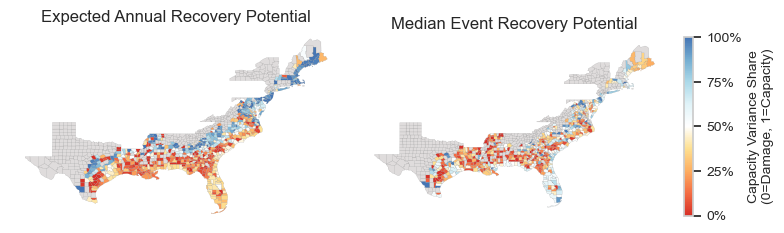

In [13]:
# ============================================================================
# SPATIAL MAP: Annual Variance Shares
# ============================================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

print("Creating spatial map of ANNUAL variance shares...")

# Merge with geodataframe
gdf_variance_annual = coastal_counties.merge(
    driver_analysis[['fips', 'share_damage', 'share_capacity', 
                     'dominant_driver_variance_annual']],
    left_on='GEOID',
    right_on='fips',
    how='left'
)

# ============================================================================
# SIDE-BY-SIDE: Annual vs Per-Event Maps
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Diverging colormap
colors_diverging = ['#d73027', '#f46d43', '#fdae61', '#fee090', '#ffffff',
                    '#e0f3f8', '#abd9e9', '#74add1', '#4575b4']
cmap = LinearSegmentedColormap.from_list('damage_capacity', colors_diverging, N=256)

# ===================== LEFT: ANNUAL (EARP) =====================
ax1 = axes[0]

gdf_variance_annual.plot(
    column='share_capacity',
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidth=0.1,
    edgecolor='0.5',
    legend=False,
    ax=ax1,
    missing_kwds={'color': '#dfdcdc', 'label': 'No data'}
)

# ax1.set_xlim(-130, -65)
# ax1.set_ylim(24, 50)
ax1.set_title('Expected Annual Recovery Potential',
             fontsize=12)
ax1.axis('off')

# Text box for annual
# textstr_annual = (f'Annual Metrics:\n'
#                   f'log(EARP) = {beta_0_annual:.2f} + {beta_D_annual:+.2f}·log(EAD)\n'
#                   f'                + {beta_C_annual:+.2f}·log(Capacity)\n\n'
#                   f'R² = {r2_annual:.3f}\n\n'
#                   f'Median damage share: {data_annual["share_damage"].median():.3f}\n'
#                   f'Median capacity share: {data_annual["share_capacity"].median():.3f}')
# props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5)
# ax1.text(0.02, 0.98, textstr_annual, transform=ax1.transAxes, fontsize=9,
#         verticalalignment='top', bbox=props, family='monospace')

#ax1.text(0.02, 0.02, 'a', transform=ax1.transAxes, fontsize=16, fontweight='bold')

# ===================== RIGHT: PER-EVENT (Median) =====================
ax2 = axes[1]

# Use the per-event data merged earlier
gdf_variance_event = coastal_counties.merge(
    per_event_analysis_median[['fips', 'share_damage', 'share_capacity', 
                                'dominant_driver_variance']],
    left_on='GEOID',
    right_on='fips',
    how='left'
)

gdf_variance_event.plot(
    column='share_capacity',
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidth=0.1,
    edgecolor='0.5',
    legend=False,
    ax=ax2,
    missing_kwds={'color': '#dfdcdc', 'label': 'No data'}
)

# ax2.set_xlim(-130, -65)
# ax2.set_ylim(24, 50)
ax2.set_title('Median Event Recovery Potential',
             fontsize=12)
ax2.axis('off')

# Text box for per-event
# textstr_event = (f'Per-Event Metrics:\n'
#                  f'log(R) = {beta_0:.2f} + {beta_D:+.2f}·log(Damage)\n'
#                  f'             + {beta_C:+.2f}·log(Capacity)\n\n'
#                  f'R² = {r2:.3f}\n\n'
#                  f'Median damage share: {data["share_damage"].median():.3f}\n'
#                  f'Median capacity share: {data["share_capacity"].median():.3f}')
# ax2.text(0.02, 0.98, textstr_event, transform=ax2.transAxes, fontsize=9,
#         verticalalignment='top', bbox=props, family='monospace')

#ax2.text(0.02, 0.02, 'b', transform=ax2.transAxes, fontsize=16, fontweight='bold')

# Shared colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="3%", pad=0.15)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Capacity Variance Share\n(0=Damage, 1=Capacity)', 
               fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("../analysis_output/variance_share_annual_vs_event_maps.png", dpi=300, bbox_inches="tight")
plt.show()
